In [26]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.io import arff
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler, StandardScaler
from catboost import CatBoostClassifier

warnings.filterwarnings('ignore')
RANDOM_STATE = 42


In [27]:
raw_data, _ = arff.loadarff('bank.arff')

df = pd.DataFrame(raw_data)

for col in df.columns:
    if df[col].dtype == object:
        df[col] = df[col].str.decode('utf-8')

df = df.rename(columns={
    'V1': 'age', 'V2': 'job', 'V3': 'marital', 'V4': 'education',
    'V5': 'default', 'V6': 'balance', 'V7': 'housing', 'V8': 'loan',
    'V9': 'contact', 'V10': 'day', 'V11': 'month', 'V12': 'duration',
    'V13': 'campaign', 'V14': 'pdays', 'V15': 'previous', 'V16': 'poutcome',
    'Class': 'y',
})

df['y'] = df['y'].map({'1': 'no', '2': 'yes'})

cat_cols = [
    'job', 'marital', 'education', 'default', 'housing', 'loan',
    'contact', 'month', 'poutcome',
]
num_cols = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

for col in cat_cols + ['y']:
    df[col] = df[col].astype('category')

df[num_cols] = df[num_cols].astype('int64')

print(df.shape)
print('доля yes:', (df['y'] == 'yes').mean())
df.head()


(45211, 17)
доля yes: 0.11698480458295547


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [28]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   age        45211 non-null  int64   
 1   job        45211 non-null  category
 2   marital    45211 non-null  category
 3   education  45211 non-null  category
 4   default    45211 non-null  category
 5   balance    45211 non-null  int64   
 6   housing    45211 non-null  category
 7   loan       45211 non-null  category
 8   contact    45211 non-null  category
 9   day        45211 non-null  int64   
 10  month      45211 non-null  category
 11  duration   45211 non-null  int64   
 12  campaign   45211 non-null  int64   
 13  pdays      45211 non-null  int64   
 14  previous   45211 non-null  int64   
 15  poutcome   45211 non-null  category
 16  y          45211 non-null  category
dtypes: category(10), int64(7)
memory usage: 2.8 MB


In [29]:
print('пропуски:')
print(df.isna().sum())
print('дубликаты:', df.duplicated().sum())

df['y'].value_counts()


пропуски:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64
дубликаты: 0


y
no     39922
yes     5289
Name: count, dtype: int64

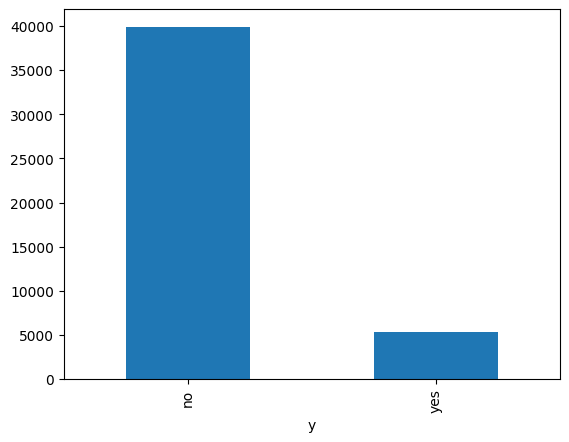

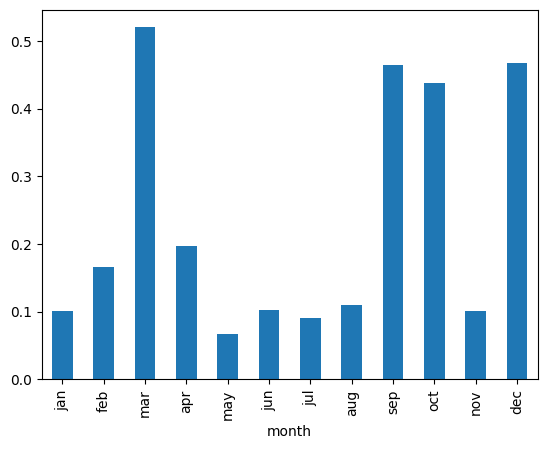

In [30]:
df['y'].value_counts().plot(kind='bar')
plt.show()

month_order = ['jan', 'feb', 'mar', 'apr', 'may', 'jun',
               'jul', 'aug', 'sep', 'oct', 'nov', 'dec']

yes_by_month = df.groupby('month', observed=True)['y'].apply(lambda s: (s == 'yes').mean())
yes_by_month = yes_by_month.reindex(month_order)
yes_by_month.plot(kind='bar')
plt.show()


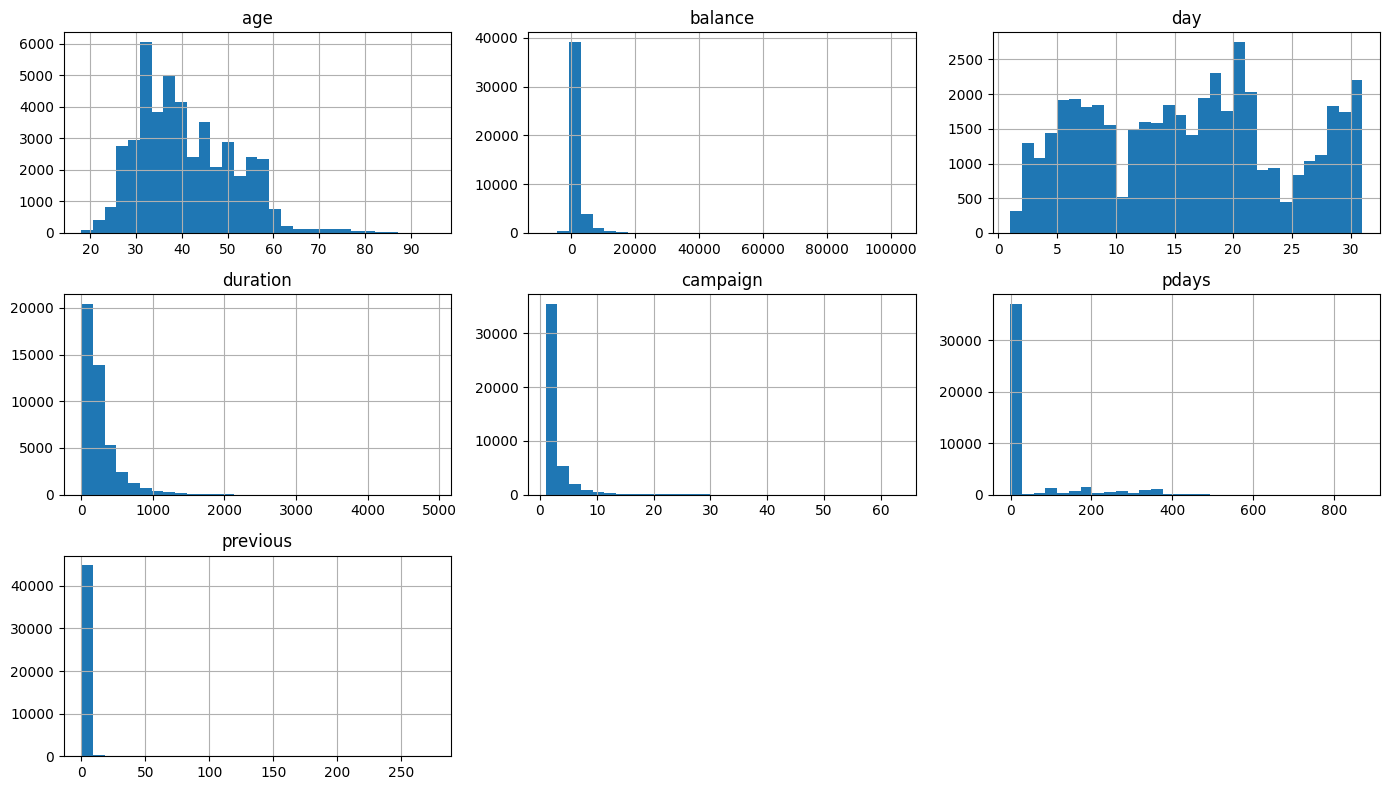

In [31]:
df[num_cols].hist(bins=30, figsize=(14, 8))
plt.tight_layout()
plt.show()


In [32]:
for col in cat_cols:
    print(col)
    print(df[col].value_counts())
    print()


job
job
blue-collar      9732
management       9458
technician       7597
admin.           5171
services         4154
retired          2264
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           938
unknown           288
Name: count, dtype: int64

marital
marital
married     27214
single      12790
divorced     5207
Name: count, dtype: int64

education
education
secondary    23202
tertiary     13301
primary       6851
unknown       1857
Name: count, dtype: int64

default
default
no     44396
yes      815
Name: count, dtype: int64

housing
housing
yes    25130
no     20081
Name: count, dtype: int64

loan
loan
no     37967
yes     7244
Name: count, dtype: int64

contact
contact
cellular     29285
unknown      13020
telephone     2906
Name: count, dtype: int64

month
month
may    13766
jul     6895
aug     6247
jun     5341
nov     3970
apr     2932
feb     2649
jan     1403
oct      738
sep      579
mar      477
dec      214
Name: count,

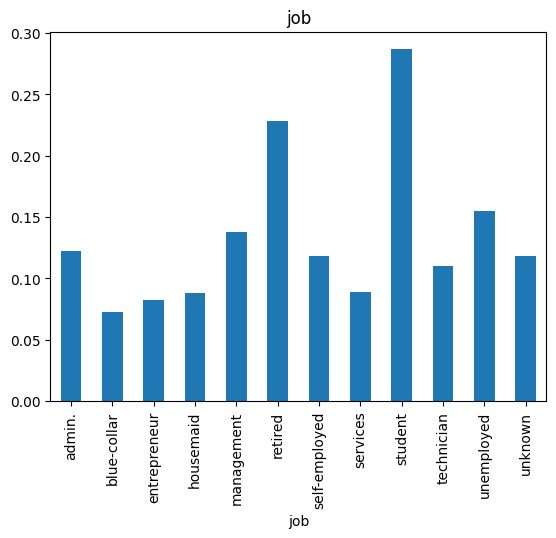

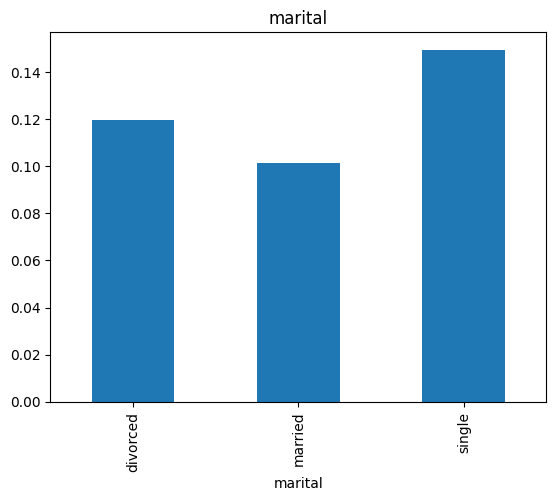

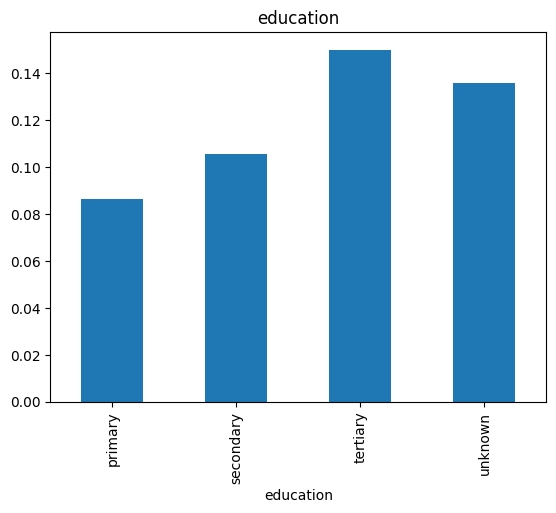

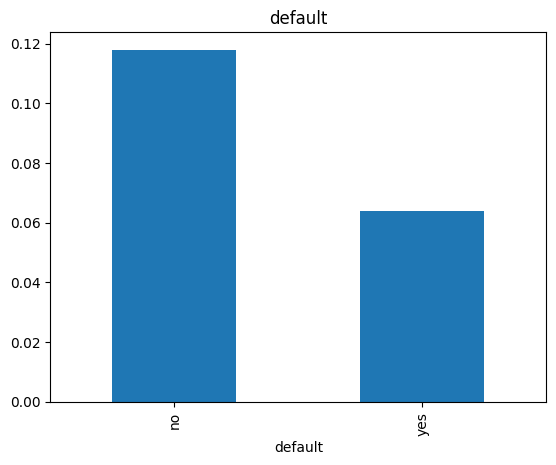

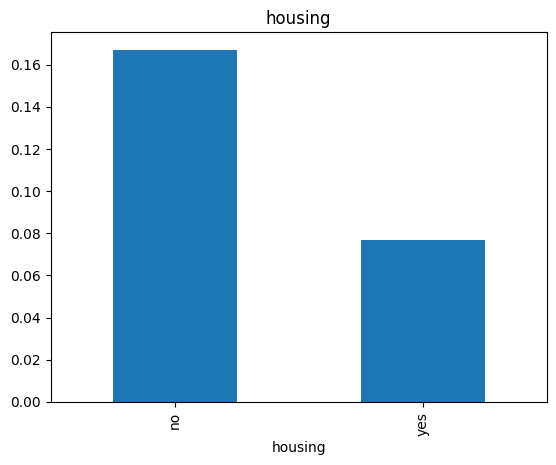

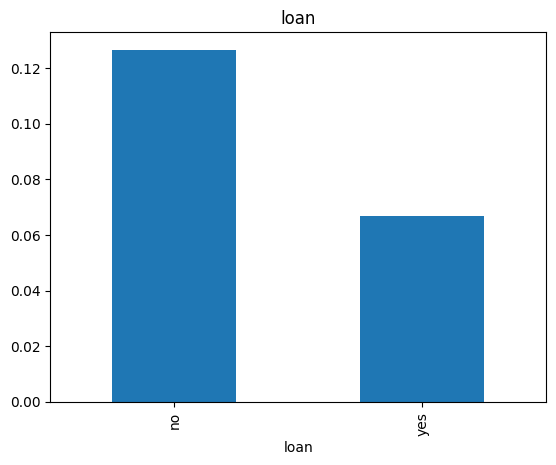

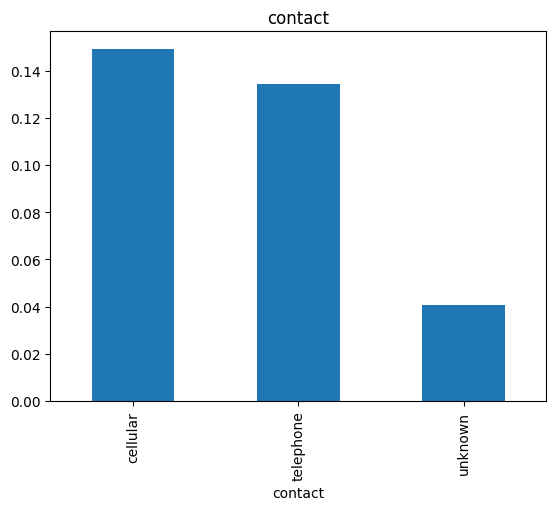

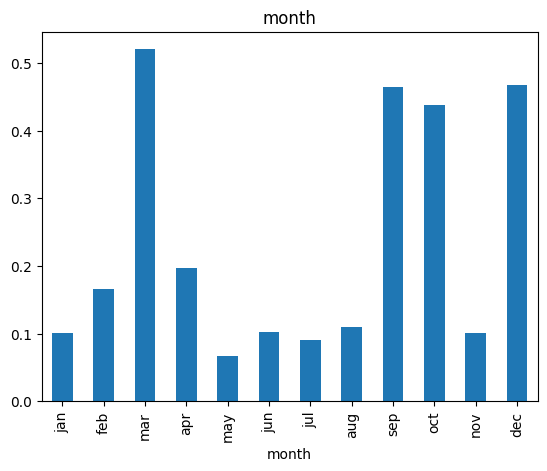

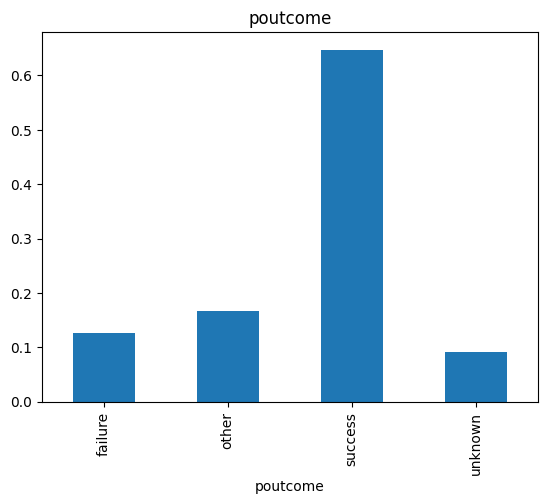

In [33]:
for col in cat_cols:
    rates = df.groupby(col, observed=True)['y'].apply(lambda s: (s == 'yes').mean())
    if col == 'month':
        rates = rates.reindex(month_order)
    rates.plot(kind='bar', title=col)
    plt.show()


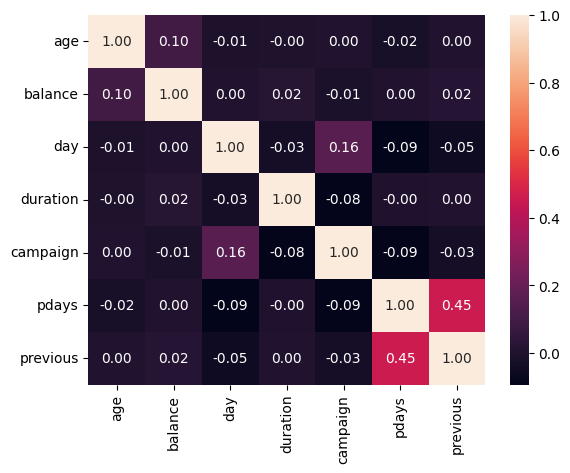

,age,balance,day,duration,campaign,pdays,previous
age,1.000000,0.097783,-0.009120,-0.004648,0.004760,-0.023758,0.001288
balance,0.097783,1.000000,0.004503,0.021560,-0.014578,0.003435,0.016674
day,-0.009120,0.004503,1.000000,-0.030206,0.162490,-0.093044,-0.051710
duration,-0.004648,0.021560,-0.030206,1.000000,-0.084570,-0.001565,0.001203
campaign,0.004760,-0.014578,0.162490,-0.084570,1.000000,-0.088628,-0.032855
pdays,-0.023758,0.003435,-0.093044,-0.001565,-0.088628,1.000000,0.454820
previous,0.001288,0.016674,-0.051710,0.001203,-0.032855,0.454820,1.000000


In [34]:
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f')
plt.show()
corr


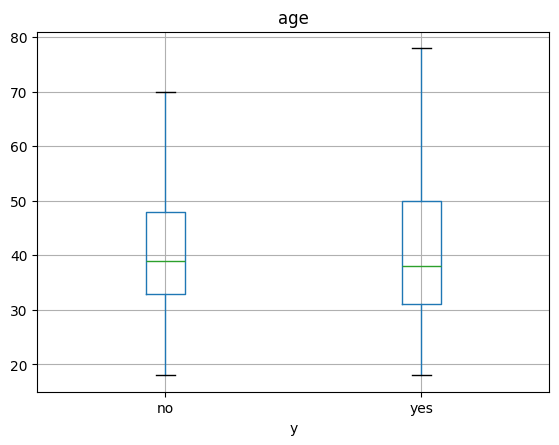

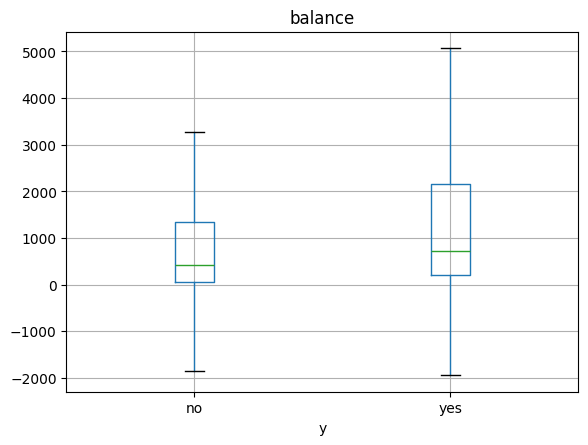

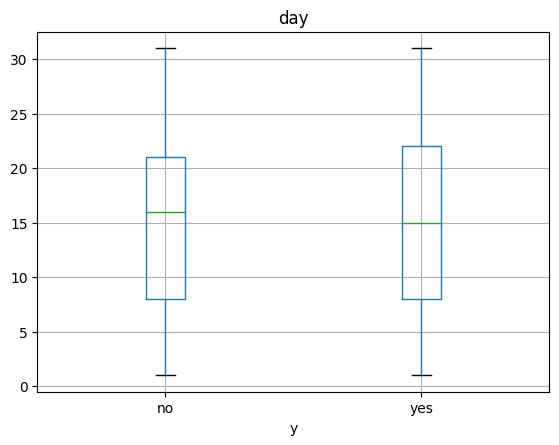

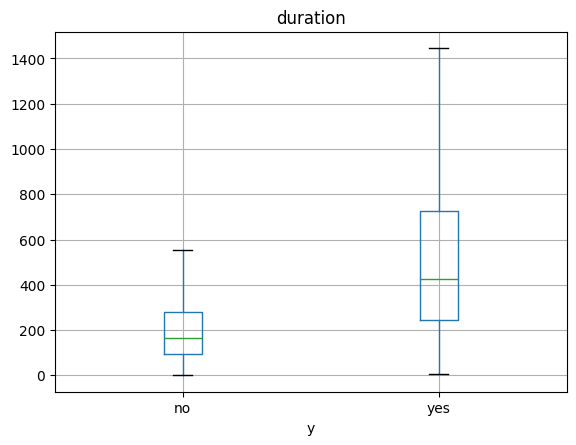

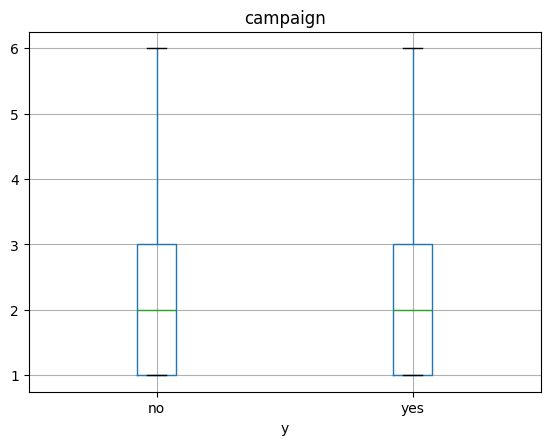

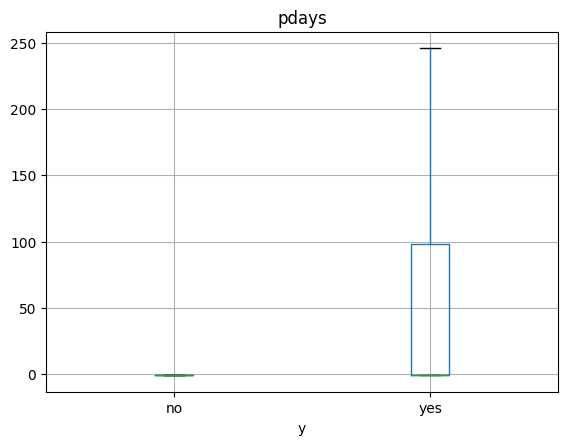

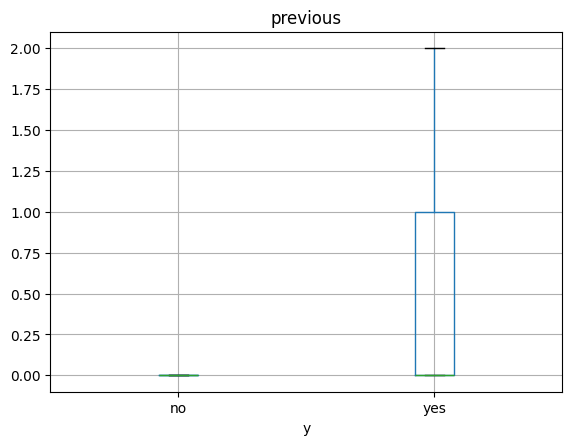

In [35]:
for col in num_cols:
    df.boxplot(column=col, by='y', showfliers=False)
    plt.suptitle('')
    plt.show()


In [36]:
df = df.drop(columns=['duration'])

df['was_contacted_before'] = (df['pdays'] != -1).astype(int)
df.loc[df['pdays'] == -1, 'pdays'] = 0
df['y_bin'] = (df['y'] == 'yes').astype(int)

cat_features = [
    'job', 'marital', 'education', 'default', 'housing', 'loan',
    'contact', 'month', 'poutcome',
]
num_features = ['age', 'balance', 'day', 'campaign', 'pdays', 'previous', 'was_contacted_before']

print(df.shape)
print('доля yes:', df['y_bin'].mean())
df[cat_features + num_features + ['y_bin']].head()


(45211, 18)
доля yes: 0.11698480458295547


,job,marital,education,default,housing,loan,contact,month,poutcome,age,balance,day,campaign,pdays,previous,was_contacted_before,y_bin
0,management,married,tertiary,no,yes,no,unknown,may,unknown,58,2143,5,1,0,0,0,0
1,technician,single,secondary,no,yes,no,unknown,may,unknown,44,29,5,1,0,0,0,0
2,entrepreneur,married,secondary,no,yes,yes,unknown,may,unknown,33,2,5,1,0,0,0,0
3,blue-collar,married,unknown,no,yes,no,unknown,may,unknown,47,1506,5,1,0,0,0,0
4,unknown,single,unknown,no,no,no,unknown,may,unknown,33,1,5,1,0,0,0,0


In [37]:
n = len(df)
train_end = int(n * 0.6)
val_end = int(n * 0.8)

train_df = df.iloc[:train_end]
val_df = df.iloc[train_end:val_end]
test_df = df.iloc[val_end:]

print('train:', train_df.shape, 'yes=', train_df['y_bin'].mean())
print('val:  ', val_df.shape, 'yes=', val_df['y_bin'].mean())
print('test: ', test_df.shape, 'yes=', test_df['y_bin'].mean())


train: (27126, 18) yes= 0.05039445550394456
val:   (9042, 18) yes= 0.11789427117894272
test:  (9043, 18) yes= 0.31582439455932765


In [38]:
def score_prep(scaler, use_was_contacted):
    nums = ['age', 'balance', 'day', 'campaign', 'pdays', 'previous']
    if use_was_contacted:
        nums = nums + ['was_contacted_before']

    cols = cat_features + nums
    X_tr = train_df[cols]
    y_tr = train_df['y_bin']
    X_va = val_df[cols]
    y_va = val_df['y_bin']

    pipe = Pipeline([
        ('pre', ColumnTransformer([
            ('num', scaler, nums),
            ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features),
        ])),
        ('model', LogisticRegression(
            max_iter=10000,
            class_weight='balanced',
            random_state=RANDOM_STATE,
        )),
    ])
    pipe.fit(X_tr, y_tr)
    proba = pipe.predict_proba(X_va)[:, 1]
    return average_precision_score(y_va, proba)


ablation = pd.DataFrame([
    {'scaler': 'StandardScaler', 'was_contacted_before': 'да',
     'PR-AUC (val)': score_prep(StandardScaler(), True)},
    {'scaler': 'RobustScaler', 'was_contacted_before': 'да',
     'PR-AUC (val)': score_prep(RobustScaler(), True)},
    {'scaler': 'StandardScaler', 'was_contacted_before': 'нет',
     'PR-AUC (val)': score_prep(StandardScaler(), False)},
    {'scaler': 'RobustScaler', 'was_contacted_before': 'нет',
     'PR-AUC (val)': score_prep(RobustScaler(), False)},
])
ablation = ablation.sort_values('PR-AUC (val)', ascending=False).reset_index(drop=True)
ablation


,scaler,was_contacted_before,PR-AUC (val)
0,StandardScaler,да,0.162743
1,RobustScaler,нет,0.162576
2,RobustScaler,да,0.162396
3,StandardScaler,нет,0.162284


In [39]:
best = ablation.iloc[0]
use_was = best['was_contacted_before'] == 'да'
scaler_name = best['scaler']
print(best)

if use_was:
    num_features = ['age', 'balance', 'day', 'campaign', 'pdays', 'previous', 'was_contacted_before']
else:
    num_features = ['age', 'balance', 'day', 'campaign', 'pdays', 'previous']

feature_cols = cat_features + num_features

X_train = train_df[feature_cols]
y_train = train_df['y_bin']
X_val = val_df[feature_cols]
y_val = val_df['y_bin']
X_test = test_df[feature_cols]
y_test = test_df['y_bin']


scaler                  StandardScaler
was_contacted_before                да
PR-AUC (val)                  0.162743
Name: 0, dtype: object


In [40]:
def make_scaler():
    if scaler_name == 'RobustScaler':
        return RobustScaler()
    return StandardScaler()


def get_metrics(model, X, y):
    proba = model.predict_proba(X)[:, 1]
    pred = (proba >= 0.5).astype(int)
    return {
        'roc_auc': roc_auc_score(y, proba),
        'pr_auc': average_precision_score(y, proba),
        'precision': precision_score(y, pred, zero_division=0),
        'recall': recall_score(y, pred, zero_division=0),
        'f1': f1_score(y, pred, zero_division=0),
    }


def fit_logreg(name, model, param_grid=None):
    pipe = Pipeline([
        ('pre', ColumnTransformer([
            ('num', make_scaler(), num_features),
            ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features),
        ])),
        ('model', model),
    ])

    if param_grid is None:
        pipe.fit(X_train, y_train)
        best_pipe = pipe
        best_params = {}
    else:
        grid = GridSearchCV(pipe, param_grid, scoring='average_precision', cv=3, n_jobs=-1)
        grid.fit(X_train, y_train)
        best_pipe = grid.best_estimator_
        best_params = grid.best_params_

    val_m = get_metrics(best_pipe, X_val, y_val)
    test_m = get_metrics(best_pipe, X_test, y_test)
    return {
        'model': name,
        'best_params': best_params,
        'PR-AUC (val)': val_m['pr_auc'],
        'ROC-AUC (val)': val_m['roc_auc'],
        'F1 (val)': val_m['f1'],
        'PR-AUC (test)': test_m['pr_auc'],
        'ROC-AUC (test)': test_m['roc_auc'],
        'F1 (test)': test_m['f1'],
        'fitted': best_pipe,
    }


In [41]:
C_GRID = np.logspace(-3, 2, 8)

results = []

results.append(fit_logreg(
    'LogReg (none)',
    LogisticRegression(
        penalty=None, solver='lbfgs', max_iter=10000,
        class_weight='balanced', random_state=RANDOM_STATE,
    ),
))

results.append(fit_logreg(
    'LogReg L2',
    LogisticRegression(
        penalty='l2', solver='lbfgs', max_iter=10000,
        class_weight='balanced', random_state=RANDOM_STATE,
    ),
    param_grid={'model__C': C_GRID},
))

results.append(fit_logreg(
    'LogReg L1',
    LogisticRegression(
        penalty='l1', solver='saga', max_iter=10000,
        class_weight='balanced', random_state=RANDOM_STATE,
    ),
    param_grid={'model__C': C_GRID},
))

results.append(fit_logreg(
    'LogReg ElasticNet',
    LogisticRegression(
        penalty='elasticnet', solver='saga', max_iter=10000,
        class_weight='balanced', random_state=RANDOM_STATE,
    ),
    param_grid={'model__C': C_GRID, 'model__l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]},
))

metrics_df = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ('fitted', 'best_params')} for r in results
])
metrics_df = metrics_df.sort_values('PR-AUC (val)', ascending=False).reset_index(drop=True)
metrics_df


,model,PR-AUC (val),ROC-AUC (val),F1 (val),PR-AUC (test),ROC-AUC (test),F1 (test)
0,LogReg L2,0.167624,0.602332,0.235067,0.393614,0.599090,0.446516
1,LogReg (none),0.162959,0.621607,0.256162,0.442220,0.669264,0.524239
2,LogReg L1,0.117894,0.500000,0.000000,0.315824,0.500000,0.000000
3,LogReg ElasticNet,0.117894,0.500000,0.210922,0.315824,0.500000,0.480040


In [42]:
X_train_cb = X_train.copy()
X_val_cb = X_val.copy()
X_test_cb = X_test.copy()

for col in cat_features:
    X_train_cb[col] = X_train_cb[col].astype(str)
    X_val_cb[col] = X_val_cb[col].astype(str)
    X_test_cb[col] = X_test_cb[col].astype(str)

best_cb = None
best_cb_score = -1

for depth in [4, 6]:
    for lr in [0.03, 0.05, 0.1]:
        for l2 in [1, 3, 10]:
            model = CatBoostClassifier(
                loss_function='Logloss',
                auto_class_weights='Balanced',
                random_seed=RANDOM_STATE,
                verbose=False,
                iterations=500,
                depth=depth,
                learning_rate=lr,
                l2_leaf_reg=l2,
                od_type='Iter',
                od_wait=50,
            )
            model.fit(
                X_train_cb, y_train,
                cat_features=cat_features,
                eval_set=(X_val_cb, y_val),
                use_best_model=True,
            )
            val_m = get_metrics(model, X_val_cb, y_val)
            test_m = get_metrics(model, X_test_cb, y_test)
            if val_m['pr_auc'] > best_cb_score:
                best_cb_score = val_m['pr_auc']
                best_cb = {
                    'model': 'CatBoost',
                    'best_params': {
                        'depth': depth,
                        'learning_rate': lr,
                        'l2_leaf_reg': l2,
                        'best_iteration': model.get_best_iteration(),
                    },
                    'PR-AUC (val)': val_m['pr_auc'],
                    'ROC-AUC (val)': val_m['roc_auc'],
                    'F1 (val)': val_m['f1'],
                    'PR-AUC (test)': test_m['pr_auc'],
                    'ROC-AUC (test)': test_m['roc_auc'],
                    'F1 (test)': test_m['f1'],
                    'fitted': model,
                    'is_catboost': True,
                }

results.append(best_cb)

metrics_df = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ('fitted', 'best_params', 'is_catboost')} for r in results
])
metrics_df = metrics_df.sort_values('PR-AUC (val)', ascending=False).reset_index(drop=True)
metrics_df


,model,PR-AUC (val),ROC-AUC (val),F1 (val),PR-AUC (test),ROC-AUC (test),F1 (test)
0,CatBoost,0.178623,0.607964,0.221624,0.445216,0.686440,0.555155
1,LogReg L2,0.167624,0.602332,0.235067,0.393614,0.599090,0.446516
2,LogReg (none),0.162959,0.621607,0.256162,0.442220,0.669264,0.524239
3,LogReg L1,0.117894,0.500000,0.000000,0.315824,0.500000,0.000000
4,LogReg ElasticNet,0.117894,0.500000,0.210922,0.315824,0.500000,0.480040


In [43]:
for r in results:
    print(r['model'], r['best_params'])


LogReg (none) {}
LogReg L2 {'model__C': np.float64(0.001)}
LogReg L1 {'model__C': np.float64(0.001)}
LogReg ElasticNet {'model__C': np.float64(0.001), 'model__l1_ratio': 0.9}
CatBoost {'depth': 6, 'learning_rate': 0.1, 'l2_leaf_reg': 10, 'best_iteration': 12}


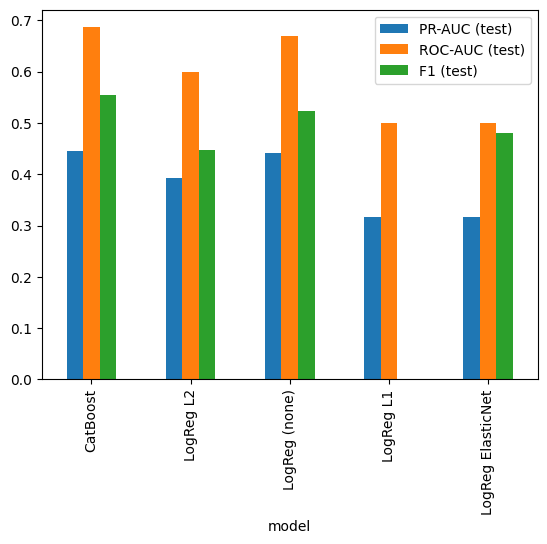

In [44]:
metrics_df.set_index('model')[['PR-AUC (test)', 'ROC-AUC (test)', 'F1 (test)']].plot(kind='bar')
plt.show()


In [45]:
best_result = max(results, key=lambda r: r['PR-AUC (val)'])
final_model = best_result['fitted']
final_name = best_result['model']
is_catboost = best_result.get('is_catboost', False)

print('final:', final_name)
print('PR-AUC val:', best_result['PR-AUC (val)'])
print('PR-AUC test:', best_result['PR-AUC (test)'])
print('params:', best_result['best_params'])

if is_catboost:
    X_test_final = X_test_cb
    X_val_final = X_val_cb
    X_train_final = X_train_cb
    importance = pd.Series(final_model.get_feature_importance(), index=feature_cols)
else:
    X_test_final = X_test
    X_val_final = X_val
    X_train_final = X_train
    pre = final_model.named_steps['pre']
    names = list(num_features) + list(pre.named_transformers_['cat'].get_feature_names_out(cat_features))
    coefs = np.abs(final_model.named_steps['model'].coef_.ravel())
    importance = pd.Series(coefs, index=names)

importance = importance.sort_values(ascending=False)
importance.head(15)


final: CatBoost
PR-AUC val: 0.17862346255224304
PR-AUC test: 0.4452162588915583
params: {'depth': 6, 'learning_rate': 0.1, 'l2_leaf_reg': 10, 'best_iteration': 12}


month        35.664761
campaign     19.137790
marital      18.034182
balance      14.579299
age           4.806173
job           2.174485
education     1.777598
day           1.316987
loan          1.076498
poutcome      1.034635
pdays         0.348206
previous      0.049386
default       0.000000
housing       0.000000
contact       0.000000
dtype: float64

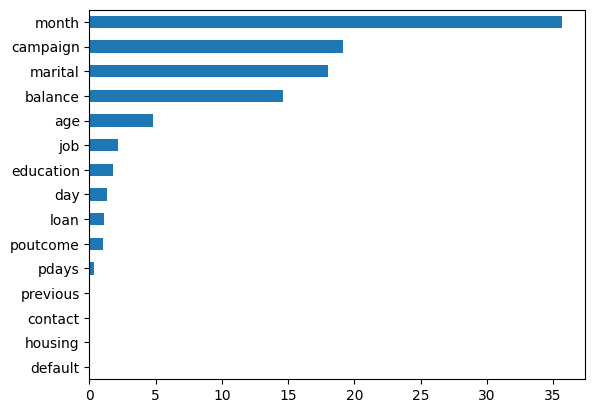

In [46]:
importance.head(15).sort_values().plot(kind='barh')
plt.show()


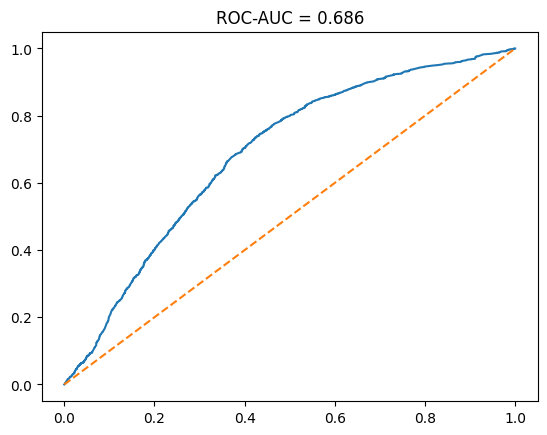

              precision    recall  f1-score   support

          no       0.83      0.56      0.67      6187
         yes       0.44      0.75      0.56      2856

    accuracy                           0.62      9043
   macro avg       0.63      0.65      0.61      9043
weighted avg       0.71      0.62      0.63      9043

[[3437 2750]
 [ 702 2154]]


In [47]:
y_test_proba = final_model.predict_proba(X_test_final)[:, 1]
y_test_pred = (y_test_proba >= 0.5).astype(int)

fpr, tpr, _ = roc_curve(y_test, y_test_proba)
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], '--')
plt.title('ROC-AUC = %.3f' % roc_auc_score(y_test, y_test_proba))
plt.show()

print(classification_report(y_test, y_test_pred, target_names=['no', 'yes']))
print(confusion_matrix(y_test, y_test_pred))


In [48]:
rows = []
for name, X, y in [('train', X_train_final, y_train),
                   ('val', X_val_final, y_val),
                   ('test', X_test_final, y_test)]:
    m = get_metrics(final_model, X, y)
    m['split'] = name
    rows.append(m)

metrics_by_split = pd.DataFrame(rows).set_index('split')
print('ROC-AUC train-val:', metrics_by_split.loc['train', 'roc_auc'] - metrics_by_split.loc['val', 'roc_auc'])
print('ROC-AUC train-test:', metrics_by_split.loc['train', 'roc_auc'] - metrics_by_split.loc['test', 'roc_auc'])
metrics_by_split


ROC-AUC train-val: 0.02859993406161454
ROC-AUC train-test: -0.04987678357289105


,roc_auc,pr_auc,precision,recall,f1
split,,,,,
train,0.636564,0.112647,0.068690,0.660571,0.124440
val,0.607964,0.178623,0.127447,0.848968,0.221624
test,0.686440,0.445216,0.439233,0.754202,0.555155
